<a href="https://colab.research.google.com/github/prishabobde/CS_181_ComputerVision/blob/main/CS181_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2    #to read in pic
import matplotlib.pyplot as plt
from scipy import ndimage  #for convololution
from scipy.signal import convolve2d



## Question 2: Gaussian and Laplacian Pyramids

In [ ]:
from google.colab import files
originalImage = files.upload()

Saving kavli-small.png to kavli-small.png


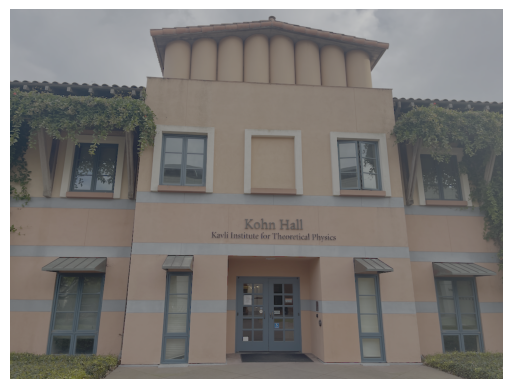

In [ ]:
originalImage = cv2.imread("kavli-small.png")
#print(originalImage)
plt.imshow(cv2.cvtColor(originalImage, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
#converting to greyscale
grayScale = cv2.cvtColor(originalImage, cv2.COLOR_BGR2GRAY)

# plt.imshow(grayScale, cmap='gray')
# plt.axis('off')
# plt.show()

In [ ]:
#croping 512 x 512 from upper left
grayCropped = grayScale[0:512, 0:512]


# plt.imshow(grayCropped, cmap='gray')
# plt.axis('off')
# plt.show()

### a) Gaussian Pyramid

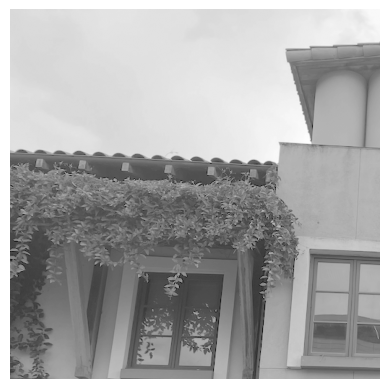

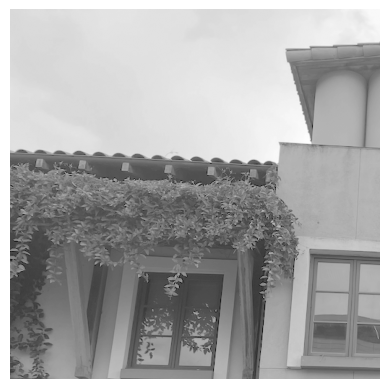

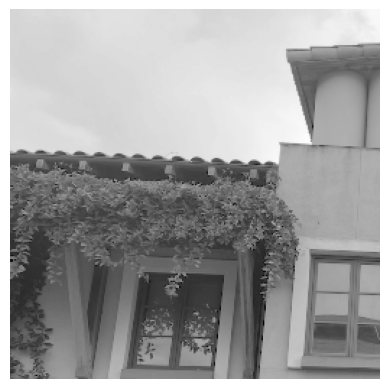

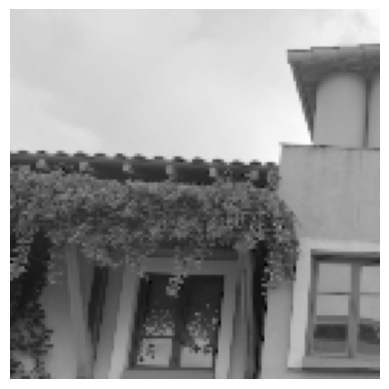

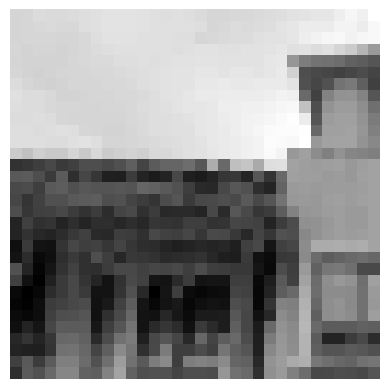

In [ ]:
# Apply convolution to smooth image; downsample by factor of 2 (take every other one); 512 --> 256 --> 128 --> 32

#print original
plt.imshow(grayCropped, cmap='gray')
plt.axis('off')
plt.show()


def gaussianConvolution(image, kernel=(5,5), sigma=0.5):      #chosen values
  newImage = cv2.GaussianBlur(image, kernel, sigma)
  downsampledImage = newImage[::2, ::2]        #every other
  return downsampledImage

next_resolutions = [256, 128, 64, 32]     #skip 64

gaussianPyramid = [grayCropped]
prevImage = grayCropped

for i in range(4):
  currImage = gaussianConvolution(prevImage)

  if currImage.shape[0] != 64:
    gaussianPyramid.append(currImage)

  prevImage = currImage

#print out levels
for i in range(4):
  plt.imshow(gaussianPyramid[i], cmap='gray')
  plt.axis('off')
  plt.show()



### b) Laplacian pyramid

Level 0: curr shape = (512, 512), upsampled shape = (512, 512)
Level 1: curr shape = (256, 256), upsampled shape = (256, 256)
Level 2: curr shape = (128, 128), upsampled shape = (128, 128)


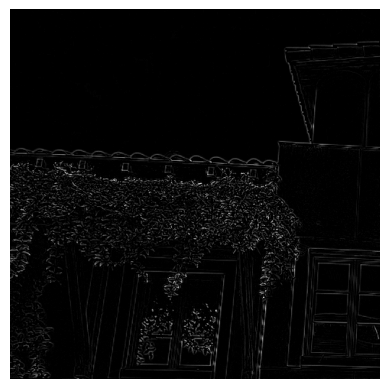

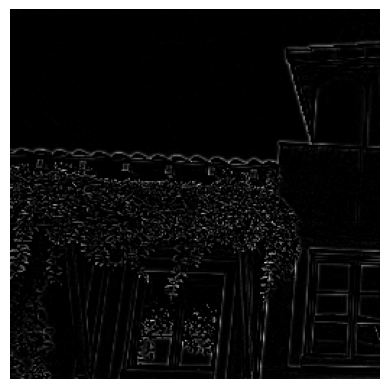

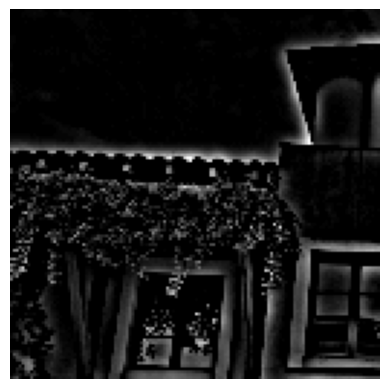

In [ ]:
# to construct Laplacian, subtract gaussian image from original
laplacianPyramid = []

for i in range(3):        # because comparing curr with next
  curr = gaussianPyramid[i]
  next = gaussianPyramid[i+1]

  upsampled = cv2.pyrUp(next)

  #we need to upsample twice when going from 138 --> 32
  if i == 2:
    upsampled = cv2.pyrUp(upsampled)

  print(f"Level {i}: curr shape = {curr.shape}, upsampled shape = {upsampled.shape}")

  #crop so they match & we can take the diff between the two
  upsampled = upsampled[:curr.shape[0], :curr.shape[1]]

  #difference between the two
  laplacian = cv2.subtract(curr, upsampled)
  laplacianPyramid.append(laplacian)

for i in range(3):
  plt.imshow(laplacianPyramid[i], cmap='gray')
  plt.axis('off')
  plt.show()



# Question 4: Implementing Harris Corner Detector

Implementing the Corner Response Function
CRF(x,y) = det(A) - k(trace(A))^2

Top 40 coordinates ordered by descending CRF:
x   | y   | CRF
---------------
760  |  92  |  17792
759  |  91  |  17792
133  |  811  |  16711
381  |  276  |  16663
1231  |  304  |  16360
573  |  99  |  16053
110  |  999  |  15665
315  |  266  |  15491
1277  |  351  |  15459
760  |  91  |  15434
1308  |  603  |  15227
1130  |  964  |  15214
166  |  1005  |  15188
985  |  438  |  15154
629  |  85  |  14902
850  |  622  |  14791
1304  |  955  |  14763
640  |  510  |  14734
148  |  999  |  14712
106  |  956  |  14567
574  |  99  |  14518
1308  |  604  |  14438
1011  |  699  |  14304
81  |  977  |  14225
278  |  494  |  14157
1098  |  329  |  13951
289  |  272  |  13860
353  |  278  |  13844
236  |  968  |  13663
315  |  267  |  13597
376  |  356  |  13300
1231  |  303  |  13241
1090  |  538  |  13237
5  |  265  |  13169
186  |  342  |  13157
133  |  965  |  13082
18  |  294  |  13066
406  |  146  |  13052
1137  |  957  |  13015
256  |  972  |  13002


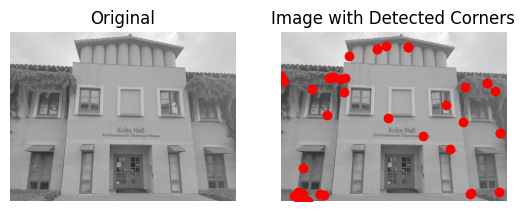

In [ ]:
# First computing A

# Calculating Ix and Iy using Sobel operators
Sx = np.array([[-1, 0, 1],
     [-2, 0, 2],
     [-1, 0, 1]])
Sy = np.array([[-1, -2, -1],
      [0, 0, 0],
      [1, 2, 1]])

Ix = ndimage.convolve(grayScale, Sx)
Iy = ndimage.convolve(grayScale, Sy)

Ixx = Ix**2
Iyy = Iy**2
Ixy = Ix * Iy

#all given equal weight --> 3 x 3
averaging = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

#each value is an array (2D) --> need to average it to get the values of A
Axx = convolve2d(Ixx, averaging)  #averaged
Ayy = convolve2d(Iyy, averaging)
Axy = convolve2d(Ixy, averaging)



def HarrisCornerDetector(image, k = 0.05, numTop = 40):
  detA = (Axx * Ayy) - Axy**2
  trace = Axx + Ayy         #sum of diagonal elements
  crf = detA - k*((trace)**2)

  #print out all crf values --> the size of all pixels
  #print("CRF:",crf)

  #print(crf.max()) = 17791.713
  threshold = 177.91713           # 1%
  meet_threshold = np.argwhere(crf > threshold)   #coordinates
  crf_values_in_range = crf[crf > threshold]

  #sorting based on crf values high to low
  topIndices = (-crf_values_in_range).argsort()[:numTop]     #negative switches the order
  topValuesInOrder = crf_values_in_range[topIndices]
  coordinatesMeetingThresholdOrdered = meet_threshold[topIndices]

  #outputing
  print("Top 40 coordinates ordered by descending CRF:")

  print("x   | y   | CRF")
  print("---------------")

  for (y, x), val in zip(coordinatesMeetingThresholdOrdered, topValuesInOrder):       #since numpy is row, col
    print(x, " | ", y, " | ", str(round(val)))


  #print both images side by side
  plt.subplot(1,2,1)        #1 row, 2 cols, 1rst subplot
  plt.imshow(grayScale, cmap='gray')
  plt.title("Original")
  plt.axis("off")

  #second image --> red dots indicated corners
  plt.subplot(1,2,2)
  plt.imshow(grayScale, cmap='gray')
  for(y,x), val in zip(coordinatesMeetingThresholdOrdered, topValuesInOrder):
    plt.plot(x,y, 'ro')
  plt.title("Image with Detected Corners")
  plt.axis("off")
  plt.show()


HarrisCornerDetector(grayScale)
